<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# **Tarea Semanal 1**
#### Nahuel Siles

Dada las siguientes topologías circuitales de un filtro Pasa Banda Pasivo:

<img src="./CircuitoTS1_a.PNG" />

Se propone reemplazar el Inductor del filtro de la Fig. 1 con un Gic:

<img src="./CircuitoTS1_b.PNG" />

## **Consignas**

1. Analizar la impedancia de entrada desde el nodo $V_X$. Hallar los valores de $R4, R5, Y1, Y2$ e $Y3$ de tal manera que responda como un Inductor de valor unitario. 
2. Obtener la función transferencia $\frac{V_2}{V_1}$. Desnormalice convenientemente en frecuencia e impedancia para garantizar una $f_0 = 10kHz$ y $Q=20$ utilizando Capacitores entre $1 nF$ y $100 nF$
3. Simule la **transferencia desnormalizada** en Python. Se sugiere programar la **transferencia normalizada** y definir las normas de frecuencia e impedancia para desnormalizar. Verificar los requerimientos pedidos en 2).
   
**Bonus**
1. Obtener los valores de $R4$ y $R5$ para obtener un Pasa Banda con $+20 dB$ de ganancia en $f_0$
2. Observe la posibilidad (no se pide realizar ninguna cuenta) de conectar un GIC en el circuito de la Fig. 2 para reemplazo del Inductor. ¿Detecta algún inconveniente o limitación?
3. Graficar la respuesta de modulo en LtSpice con el eje **Lineal** en frecuencia. Halle numericamente $BW=f_2 - f_1$ y verifique que $f_0$ es la media geométrica entre $f_2$ y $f_1$.

## **Resolución**

### **Impedancia y valores normalizados**

Primero se hallará la impedancia $Z_X$ vista desde $V_X$

In [1]:
from IPython.display import IFrame
IFrame("./Impedancia.pdf", width=1000, height=1000)

Siendo la expresion final de $Z_X$:

$$
Z_X=\frac{Y_2 R5}{Y_1 Y_3 R4} =\frac{Z_1 Z_3 R5}{Z_2 R4}
$$

y buscando que responda como un Inductor de valor unitario asumimos que $Z_1=R1 , Z_3=R3$ y $Z_2=\frac{1}{SC}$

Tomando como valores normalizados $R1'=R3'=R4'=R5'=1$ y $C''=1$ se llega a la siguiente expresion:

$$
Z_X''=\frac{1}{\frac{1}{S}}=S
$$

### **Desnormalización**

A continuación hallamos la función transferencia $\frac{V_2}{V_1}$

<img src="./Transferencia.jpeg"/>

Tomando los valores normalizados de los componentes podemos decir que:
$$
\frac{w_0}{Q} = \frac{1}{C''R'}
$$ 

$$
K=\frac{R4'+R5'}{R5'}
$$

$$
w_0^2=\frac{R4'}{R1'R3'R5'C''^2}
$$

Si una $Q=20$ , $w_0=1$ y $K=2$ nos queda la función transferencia normalizada:

$$
H(s)=\frac{S\frac{w_0}{Q} K}{s^2 + s\frac{w_0}{Q} + w_0^2}
$$

$$
H(s)=\frac{s \frac{1}{10}}{s^2 + s \frac{1}{20} + 1}
$$

Como se expreso antes, $C´´=1$, entonces:

$$
\frac{1}{20}=\frac{1}{R'}
$$

$$
R'=20
$$

Se pide una frecuencia $f_0=10kHz$ por lo que nuestra norma de frecuencia $\Omega_w$ es:

$$
\Omega_w=2\pi 10^4
$$

y aplicado a $C''$ podemos averiguar el valor de la norma de impedancia $\Omega_Z$ eligiendo como un capacitor de $10nF$:

$$
C=C´´ \frac{1}{\Omega_Z \Omega_w}
$$

$$
\Omega_Z=\frac{C''}{C\Omega_w}
$$

$$
\Omega_Z=1591
$$

Con este valor de $\Omega_Z$ desnormalizamos para averiguar los valores de los componentes:

$C=10nF$

$R=20\Omega_Z=31,820K \Omega$

$R1=1\Omega_Z=1,591K \Omega$

$R3=1\Omega_Z=1,591K \Omega$

$R4=1\Omega_Z=1,591K \Omega$

$R5=1\Omega_Z=1,591K \Omega$

### **Simulación en Python**

Cargamos las funciones y módulos necesarios para la simulación

In [4]:
# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

#%%  Inicialización de librerías
mpl.rcParams['figure.figsize'] = (10,10)

# Modificamos el largo y ancho de la salida
fig_sz_x = 14
fig_sz_y = 13
fig_dpi = 80 # dpi

# tamaño de la tipografía
fig_font_size = 11

plt.rcParams.update({'font.size':fig_font_size})

Primero simulamos la transferencia normalizada

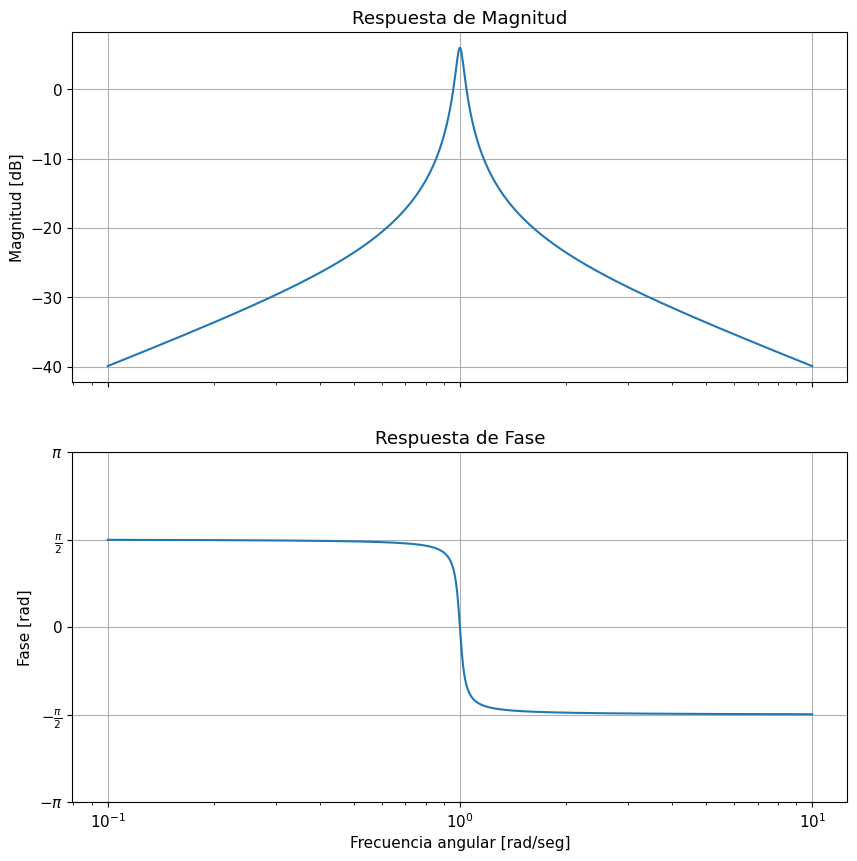

In [4]:
# Valor de Q, K y w0
Q = 20
K = 2
w0 = 1

# Función Transferencia
num = [ K * (1/Q) , 0 ]
den = [1, 1/Q , 1 ]

H1= sig.TransferFunction(num,den)

# Gráfico de módulo, fase y diagrama de Bode
_, axes_hdl = bodePlot(H1)

Ahora la desnormalizada

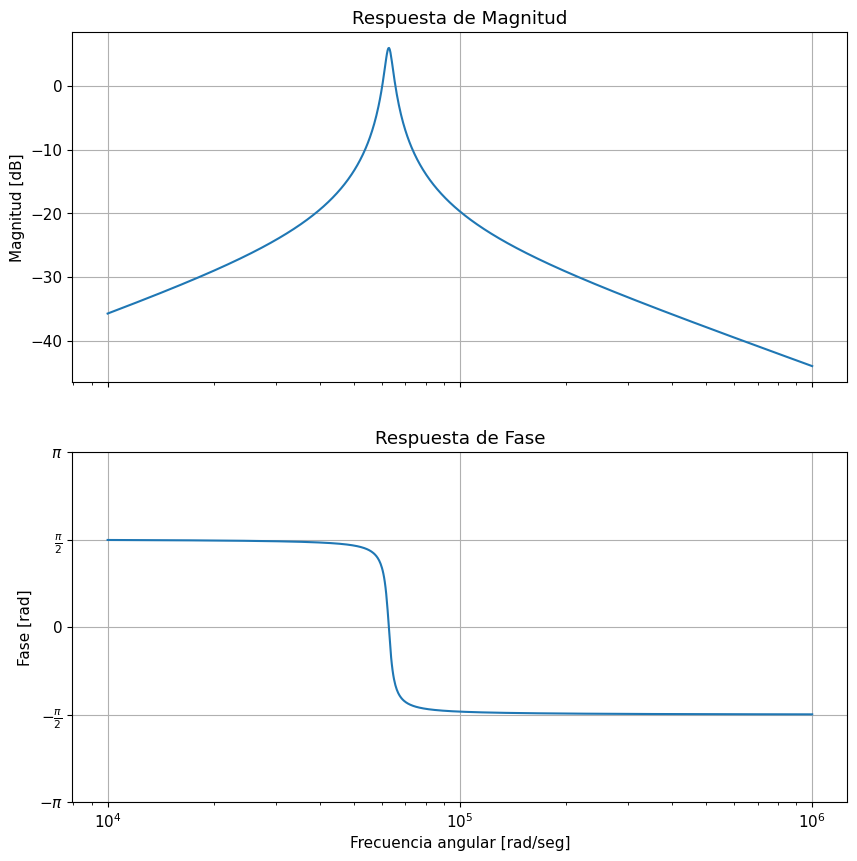

In [6]:
# Valor de Q, w0, R4 y R5
Q = 20
f0 = 10**4
w0 = 2 * np.pi * f0
R4 = 1591
R5 = 1591

# Valor de K
K = (R4 + R5) / R5

# Función Transferencia
num = ([K * (w0/Q), 0])
den = ([1, (w0/Q) , w0**2 ])

H1= sig.TransferFunction(num,den)

# Gráfico de módulo, fase y diagrama de Bode
_, axes_hdl = bodePlot(H1)

### **+20 dB de ganancia en $f_0$**

Teniendo la funcion transferencia anterior donde $w_0=1$:

$$
H(s)=K \frac{s\frac{1}{Q}}{s^2 + s\frac{1}{Q} + 1}
$$

Podemos decir que la ganancia depende de $K$ por lo que si buscamos $+20dB$ de ganancia:
$$
20log(K)=20
$$
$$
K=10
$$
Entonces las resistencias $R4'$ y $R5'$ son:
$$
\frac{R4'+R5'}{R5'} = 10
$$
$$
R4'=9R5' 
$$

Por lo que tomamos $R5'=1$ y $R4'=9$

Para el resto de las resistencias utilizamos la expresion de $w_0^2=1$

$$
1=\frac{R4'}{R1'R3'R5'}
$$

$$
R1'R3'=\frac{9R5'}{R5'}
$$

$$
R1'R3'=9
$$

Si $R1'$ y $R3'$ son iguales entonces $R1'=3$ y $R3'=3$.

Los nuevos valores de los componentes entonces son:

$C=10nF$

$R=20\Omega_Z=31,820K \Omega$

$R1=3\Omega_Z=4,773K \Omega$

$R3=3\Omega_Z=4,773K \Omega$

$R4=9\Omega_Z=14,319K \Omega$

$R5=1\Omega_Z=1,591K \Omega$

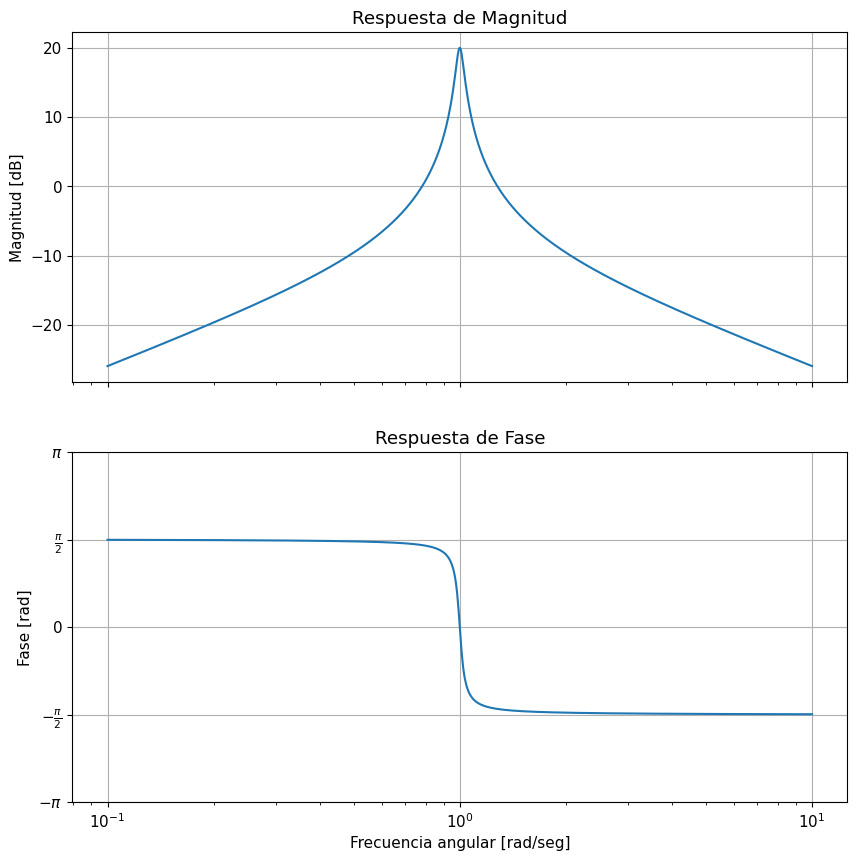

In [5]:
# Valor de Q, K y w0
Q = 20
K = 10
w0 = 1

# Función Transferencia
num = [ K * (1/Q) , 0 ]
den = [1, 1/Q , 1 ]

H1= sig.TransferFunction(num,den)

# Gráfico de módulo, fase y diagrama de Bode
_, axes_hdl = bodePlot(H1)

### **Ancho de Banda**

A continuación se calculará el ancho de banda del filtro

<img src="./Byf0.jpeg"/>

Corroboramos este resultado mediante una simulación con LtSpice en la cual se toma el ancho de banda en aproximadamente 3db ya que el pico maximo ocurre en aproximadamente 6db

<img src="./AnchoBanda.PNG"/>